# Marketing Mix Modeling: Channel Contributions and Budget Implications

## Scenario
Following the MMM baseline, extract channel-level contribution signals from the
model coefficients and translate them into a directional budget recommendation.

## Data: `mealkit_marketing_weekly.csv`


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path('Exercise_Data')
if not DATA_DIR.exists():
    DATA_DIR = Path('/content/drive/Othercomputers/My PC/Desktop/All_Work_Related/Udacity/Applied_Statistics_ND/Exercises/Udacity Exercises Redone/')

MMM_PATH = DATA_DIR / 'mealkit_marketing_weekly.csv'
from sklearn.linear_model import Ridge

df = pd.read_csv(MMM_PATH)
df['date'] = pd.to_datetime(df['date'])

## Step 1: Refit MMM (same setup as baseline)

In [7]:
def apply_adstock(series, alpha=0.3):
    result = np.zeros(len(series))
    result[0] = series.iloc[0]
    for i in range(1, len(series)):
        result[i] = series.iloc[i] + alpha * result[i-1]
    return pd.Series(result, index=series.index)

spend_cols   = ['spend_search','spend_social','spend_influencer','spend_email','spend_affiliate']
adstock_cols = [c.replace('spend_','adstock_') for c in spend_cols]
for sc, ac in zip(spend_cols, adstock_cols):
    df[ac] = apply_adstock(df[sc], alpha=0.3)
print("Adstock columns created:", adstock_cols)
df['t']     = range(1, len(df) + 1)   # linear trend
df['sin52'] = np.sin(2 * np.pi * df['t'] / 52)   # annual seasonality (sine)
df['cos52'] = np.cos(2 * np.pi * df['t'] / 52)   # annual seasonality (cosine)
feat_cols = adstock_cols + ['t', 'sin52', 'cos52']
print("Time controls added. Total features:", len(feat_cols))
split_idx = int(len(df)*0.80)
train = df.iloc[:split_idx]; test = df.iloc[split_idx:]
model = Ridge(alpha=1.0)
model.fit(train[feat_cols].astype(float), train['weekly_revenue'].astype(float))
print("Model refitted.")

Adstock columns created: ['adstock_search', 'adstock_social', 'adstock_influencer', 'adstock_email', 'adstock_affiliate']
Time controls added. Total features: 8
Model refitted.


## Step 2: Extract Channel Coefficients

In [8]:
# Adstock columns only — exclude time controls
n_channels = len(adstock_cols)
channel_coefs = pd.DataFrame({
    'channel':     adstock_cols,
    'coefficient': model.coef_[:n_channels]
}).sort_values('coefficient', ascending=False)

print("Channel coefficients (sorted by value):")
print(channel_coefs.to_string(index=False))

Channel coefficients (sorted by value):
           channel  coefficient
adstock_influencer     0.090335
    adstock_search     0.048840
 adstock_affiliate    -0.535868
    adstock_social    -0.869718
     adstock_email    -3.059488


## Step 3: Channel Coefficient Bar Chart

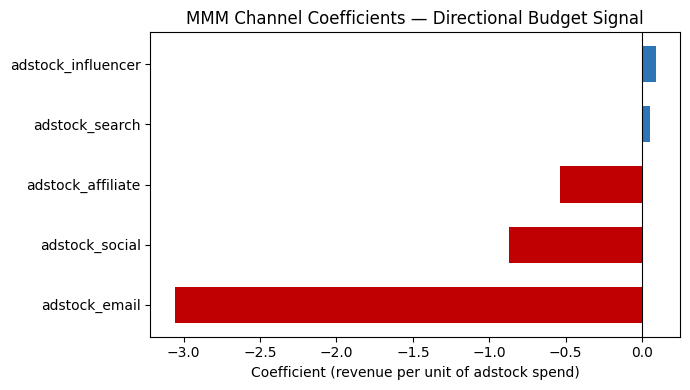

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#2E75B6' if c > 0 else '#C00000' for c in channel_coefs['coefficient']]
ax.barh(channel_coefs['channel'][::-1], channel_coefs['coefficient'][::-1],
        color=colors[::-1], height=0.6)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient (revenue per unit of adstock spend)')
ax.set_title('MMM Channel Coefficients — Directional Budget Signal')
plt.tight_layout(); plt.show()

## Budget Recommendation

**Directional signal from the model:**

Influencer shows the strongest positive historical association with revenue
(coefficient ≈ +0.090), followed by search (≈ +0.049). Both channels
correlate with revenue increases in the historical data after controlling for
trend and seasonality.

Social, email, and affiliate show negative coefficients (social ≈ −0.87,
affiliate ≈ −0.54, email ≈ −3.06). This likely reflects these channels being
deployed more heavily during low-revenue periods or in weeks with higher
refund/promotional activity, rather than a direct causal effect on revenue.
The large negative on email in particular is a correlational artifact — email
campaigns often run in slow periods to stimulate demand — not evidence that
email is destroying revenue.

**Recommendation:**
Prioritize influencer and search budget in the next planning period, where the
historical data supports positive ROI. Flag email, social, and affiliate for
further investigation before making large cuts — run a holdout test (e.g., pause
influencer spend in one region for 4 weeks) to validate causal direction before
significant reallocation.

*"MMM results are correlational (directional), not causal."*

Do not reallocate large budget amounts based on MMM coefficients alone.
A geo-split or holdout experiment is the appropriate validation step before
significant channel reallocation.
